[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cca-cce/osm-comm/blob/main/jnb/skpm20_labs.ipynb)


# Data Analysis Labs

Download sample [dataset](https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/cod-260120.xlsx) and analyze the multivariate theoretical model illustrated below:

[![](https://mermaid.ink/img/pako:eNqVU9-L4jAQ_ldCZMGD6rZNa21OhGXl4OC4h1u4h1Mf0jRqsCYlTf2x4v9-02rVrvuyKZTkm_nmm8xMjpjrVGCKl4blK_Trz0whWKk0glupVY2csaJMzk4vimWHQhZo-oNxq02BxD4Hd5Eiq5FUi6wUigvEdW-nzVqAQy4MF3ILHoxzURQXR202rFKZnxUelRv0tnt6Qj9VKnIBP2XRX2YkSzJR3Dzk1utepRFbim_3Nv_OZnTWNpKuNkum5HudFbKHvLK3xCcP0ne5b73pdJSMbwqjxDyPHy5fo-0KjJ6T8Xz-QetVK3UuRvt6qNcbV2Kte30GkjYIiTcKEP03NB692UMm1fLSYTiIW3sXMstoZxFXn1NYo9eCdjjnl30vZcWKGcMOFIUovA9R5Xhh1-vKJoQ4XGfa0I7rum2K_3UK-SolvSYWetEgvl3LTwIvHDQsCHZXqAmre_lijN41BUNdmEIJ3YTAzFjELHIvowTm9Vut5jqe46NGAlJpKreTqV1RP99_xw68PJliak0pHLwRMA_VER-rYDNsV2IjZpjCNoU0ZnimTsDJmfqn9aahGV0uV5guWFbAqcxTZsVEMniumytqqrE1r7pUFtMwqmNgesR7TL142I-Gw2EcDEJCfJc4-AAoifpxFEdD33ODIPb9k4Pfa1G3PwgCKJ8bBlDq2Cfe6T-aRFOp?type=png)](https://mermaid.live/edit#pako:eNqVU9-L4jAQ_ldCZMGD6rZNa21OhGXl4OC4h1u4h1Mf0jRqsCYlTf2x4v9-02rVrvuyKZTkm_nmm8xMjpjrVGCKl4blK_Trz0whWKk0glupVY2csaJMzk4vimWHQhZo-oNxq02BxD4Hd5Eiq5FUi6wUigvEdW-nzVqAQy4MF3ILHoxzURQXR202rFKZnxUelRv0tnt6Qj9VKnIBP2XRX2YkSzJR3Dzk1utepRFbim_3Nv_OZnTWNpKuNkum5HudFbKHvLK3xCcP0ne5b73pdJSMbwqjxDyPHy5fo-0KjJ6T8Xz-QetVK3UuRvt6qNcbV2Kte30GkjYIiTcKEP03NB692UMm1fLSYTiIW3sXMstoZxFXn1NYo9eCdjjnl30vZcWKGcMOFIUovA9R5Xhh1-vKJoQ4XGfa0I7rum2K_3UK-SolvSYWetEgvl3LTwIvHDQsCHZXqAmre_lijN41BUNdmEIJ3YTAzFjELHIvowTm9Vut5jqe46NGAlJpKreTqV1RP99_xw68PJliak0pHLwRMA_VER-rYDNsV2IjZpjCNoU0ZnimTsDJmfqn9aahGV0uV5guWFbAqcxTZsVEMniumytqqrE1r7pUFtMwqmNgesR7TL142I-Gw2EcDEJCfJc4-AAoifpxFEdD33ODIPb9k4Pfa1G3PwgCKJ8bBlDq2Cfe6T-aRFOp)

- Perform descriptive statistics
- Perform relevant data transformations
- Perform bivariate analyses and formulate hypotheses
- Perform multiple regression analysis

## Setup and data loading

We focus on descriptive statistics and data transformation for the dataset `jnb/cod-260120.xlsx`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Improve figure readability
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

# Load data (do not coerce numeric codes like 999 to missing)
path = "cod-260120.xlsx"
path = "https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/cod-260120.xlsx"
df = pd.read_excel(path)

# Quick overview
print(df.shape)
print(df.columns[:10])

(8091, 58)
Index(['ID', 'Gender', 'Age', 'Org_type', 'Role', 'info_work', 'info_org',
       'info_vision', 'info_change', 'info_intracomm'],
      dtype='object')


## 1) Descriptive statistics

### Step 1: Inspect `Gender` and `femcomm_mgmt`

Goal: identify possible values and what the variables represent.

In [2]:
# Frequency table for Gender
print(df["Gender"].value_counts(dropna=False))

# Frequency table for femcomm_mgmt
print(df["femcomm_mgmt"].value_counts(dropna=False))

# Optional: inspect Org_type and Role labels
print(df["Org_type"].value_counts(dropna=False))
print(df["Role"].value_counts(dropna=False))

Gender
Female    4262
Male      2179
NaN       1631
Other       19
Name: count, dtype: int64
femcomm_mgmt
NaN    7685
1.0     113
4.0     103
2.0      71
5.0      63
3.0      56
Name: count, dtype: int64
Org_type
Public     6575
Private    1516
Name: count, dtype: int64
Role
Coworker                       6068
Manager                        1520
Communicator or equivalent      499
NaN                               4
Name: count, dtype: int64


### Step 2: Visualize `Gender` with a pie chart

Goal: replicate SPSS frequencies + chart.

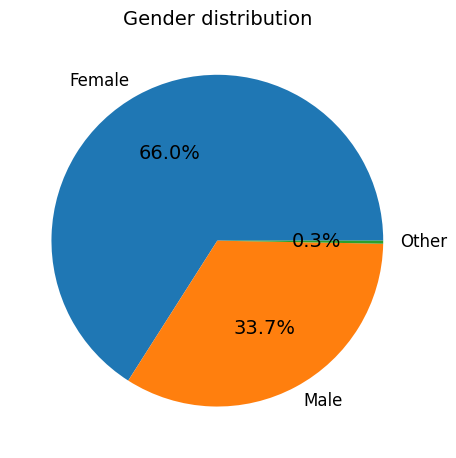

In [3]:
counts = df["Gender"].value_counts(dropna=True)
plt.figure()
plt.pie(counts.values, labels=counts.index.astype(str), autopct="%1.1f%%")
plt.title("Gender distribution")
plt.tight_layout()

Reflect: Is a pie chart a good way to visualize this variable? Would a bar chart be clearer?

### Step 3: Bar chart for `femcomm_mgmt`

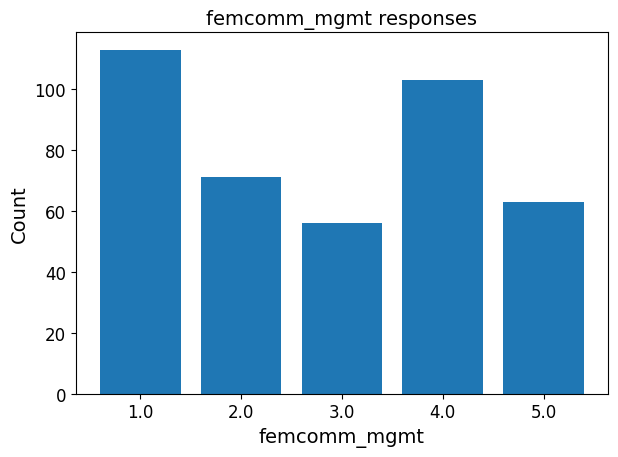

In [4]:
counts = df["femcomm_mgmt"].value_counts(dropna=True).sort_index()
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("femcomm_mgmt")
plt.ylabel("Count")
plt.title("femcomm_mgmt responses")
plt.tight_layout()

### Step 4: Bar chart for `Role`

Compare the number of valid responses here with the number of valid responses for `femcomm_mgmt`.

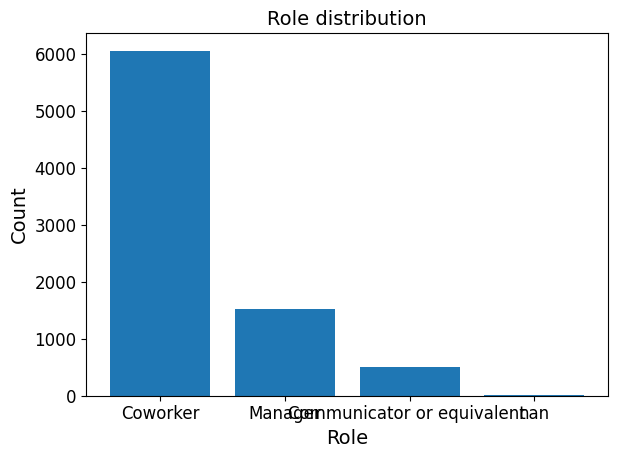

In [5]:
counts = df["Role"].value_counts(dropna=False)
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Role")
plt.ylabel("Count")
plt.title("Role distribution")
plt.tight_layout()

### Step 5: Find incorrect data in `Age`

In this dataset, `Age` is recorded as birth year. Look for unreasonable values.

count    6407.000000
mean     1967.899017
std        10.641371
min      1942.000000
25%      1959.000000
50%      1967.000000
75%      1976.000000
max      1999.000000
Name: Age, dtype: float64


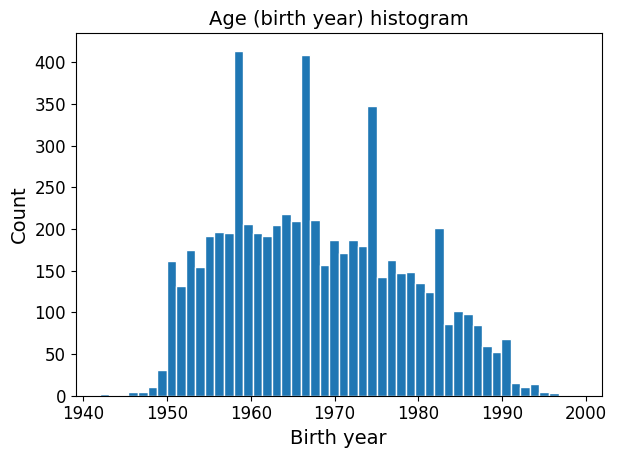

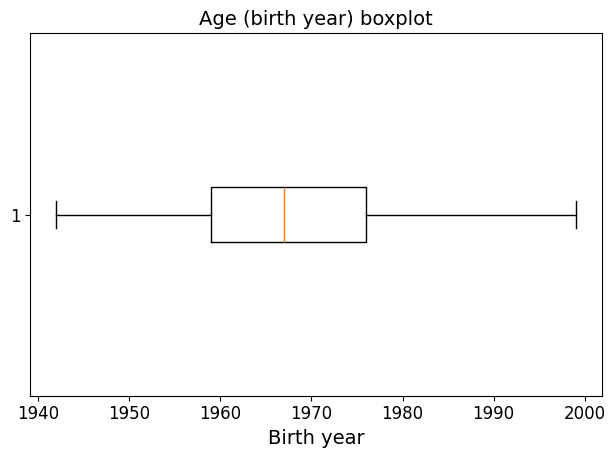

In [18]:
print(df["Age"].describe())

plt.figure()
plt.hist(df["Age"].dropna(), bins=50, edgecolor="white")
plt.xlabel("Birth year")
plt.ylabel("Count")
plt.title("Age (birth year) histogram")
plt.tight_layout()

# Boxplot for outliers
plt.figure()
plt.boxplot(df["Age"].dropna(), vert=False)
plt.xlabel("Birth year")
plt.title("Age (birth year) boxplot")
plt.tight_layout()

Identify potential outliers using the IQR rule and inspect those cases.

In [7]:
age = df["Age"].dropna()
q1, q3 = age.quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]
print(outliers[["Age"]].head(10))

         Age
3610  1182.0
3908  2084.0


If you decide values are incorrect, you can replace them with the median birth year.

In [17]:
median_birth_year = df["Age"].median()
# Example: replace outliers with the median
df.loc[(df["Age"] < lower) | (df["Age"] > upper), "Age"] = median_birth_year

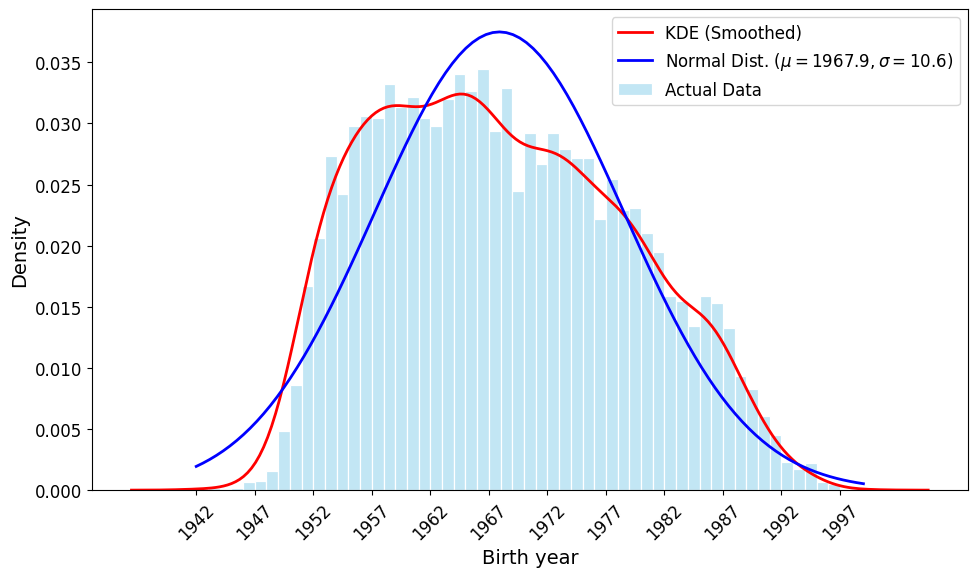

In [25]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# Clean the data
age_clean = df["Age"].dropna().astype(int)

# 1. Calculate the exact range of years
start_year = age_clean.min()
end_year = age_clean.max()

# 2. Create bins for every single year (plus one for the final edge)
# This ensures each year gets its own dedicated bar
year_bins = range(start_year, end_year + 2)

# 1. Calculate parameters
mu = age_clean.mean()
sigma = age_clean.std()

plt.figure(figsize=(10, 6))

# 2. Histogram
sns.histplot(age_clean, bins=year_bins, stat="density", color="skyblue",
             edgecolor="white", alpha=0.5, label="Actual Data")

# 3. KDE
sns.kdeplot(age_clean, color="red", linewidth=2, label="KDE (Smoothed)")

# 4. Normal Curve - Note the 'r' prefix for the label
x = np.linspace(age_clean.min(), age_clean.max(), 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'b', linewidth=2,
         label=r'Normal Dist. ($\mu={:.1f}, \sigma={:.1f}$)'.format(mu, sigma))

# Formatting
plt.xticks(range(int(age_clean.min()), int(age_clean.max()) + 1, 5), rotation=45)
plt.xlabel("Birth year")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

### Step 6: Crosstabs

#### 6a) `Gender` by `femcomm_mgmt` with column percentages

In [9]:
ct = pd.crosstab(df["femcomm_mgmt"], df["Gender"], dropna=False)
col_pct = ct.div(ct.sum(axis=0), axis=1) * 100
print(ct)
print(col_pct.round(1))

Gender        Female  Male  Other   NaN
femcomm_mgmt                           
1.0               54    51      0     8
2.0               47    21      0     3
3.0               38    16      0     2
4.0               90    11      0     2
5.0               58     2      0     3
NaN             3975  2078     19  1613
Gender        Female  Male  Other   NaN
femcomm_mgmt                           
1.0              1.3   2.3    0.0   0.5
2.0              1.1   1.0    0.0   0.2
3.0              0.9   0.7    0.0   0.1
4.0              2.1   0.5    0.0   0.1
5.0              1.4   0.1    0.0   0.2
NaN             93.3  95.4  100.0  98.9


#### 6b) `Role` by `extcomm`

In [10]:
ct = pd.crosstab(df["extcomm"], df["Role"], dropna=False)
print(ct)

Role     Communicator or equivalent   Coworker  Manager  NaN
extcomm                                                     
1.0                                1       124       23    0
2.0                                8       230       70    0
3.0                               10       750      151    1
4.0                              100      1749      535    1
5.0                              370      2007      612    0
NaN                               10      1208      129    2


### Step 7: Compare means

Compare mean age (birth year) across responses to `org_gossip`.

In [11]:
means = df.groupby("org_gossip")["Age"].mean()
print(means)

org_gossip
1.0    1968.984756
2.0    1969.316843
3.0    1967.262064
4.0    1968.218900
5.0    1967.837754
Name: Age, dtype: float64


## 2) Data transformation

### Step 1: Recode `org_gossip` into 3 categories

Recode to: 1=disagree (1,2), 2=neither (3), 3=agree (4,5).

In [12]:
# ensure numeric
org = pd.to_numeric(df["org_gossip"], errors="coerce")

def recode_org_gossip(x):
    if pd.isna(x):
        return np.nan
    if x in [1, 2]:
        return 1
    if x == 3:
        return 2
    if x in [4, 5]:
        return 3
    return np.nan


df["org_gossip_cat"] = org.apply(recode_org_gossip)

# check frequencies
print(df["org_gossip"].value_counts(dropna=False))
print(df["org_gossip_cat"].value_counts(dropna=False))

org_gossip
4.0    2263
3.0    1678
NaN    1453
5.0    1007
2.0     972
1.0     718
Name: count, dtype: int64
org_gossip_cat
3.0    3270
1.0    1690
2.0    1678
NaN    1453
Name: count, dtype: int64


Cross tab with `Role` to compare patterns more clearly.

In [13]:
ct = pd.crosstab(df["org_gossip_cat"], df["Role"], dropna=False)
print(ct)

Role            Communicator or equivalent   Coworker  Manager  NaN
org_gossip_cat                                                     
1.0                                     144      1200      344    2
2.0                                      91      1315      272    0
3.0                                     178      2349      743    0
NaN                                      86      1204      161    2


### Step 2: Compute age in years

Age is stored as birth year. Compute age in years using 2016 as the reference year.

count    6407.000000
mean       48.100983
std        10.641371
min        17.000000
25%        40.000000
50%        49.000000
75%        57.000000
max        74.000000
Name: age_years, dtype: float64


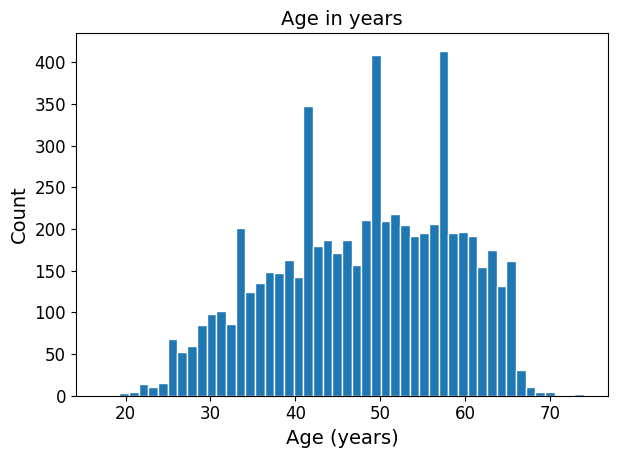

In [26]:
# Optionally fix obvious outliers before computing age in years
# df.loc[(df["Age"] < lower) | (df["Age"] > upper), "Age"] = median_birth_year

df["age_years"] = 2016 - df["Age"]
print(df["age_years"].describe())

plt.figure()
plt.hist(df["age_years"].dropna(), bins=50, edgecolor="white")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.title("Age in years")
plt.tight_layout()

### Step 3: Build an index from femcomm items

Use the items:
- `femcomm_performance`
- `femcomm_mgmt`
- `femcomm_opportunity`
- `femcomm_support`
- `femcomm_barriers`

Check coding direction before combining.

femcomm_performance
femcomm_performance
1.0     119
2.0      72
3.0      59
4.0      98
5.0      54
NaN    7689
Name: count, dtype: int64
femcomm_mgmt
femcomm_mgmt
1.0     113
2.0      71
3.0      56
4.0     103
5.0      63
NaN    7685
Name: count, dtype: int64
femcomm_opportunity
femcomm_opportunity
1.0     125
2.0      83
3.0      74
4.0      65
5.0      44
NaN    7700
Name: count, dtype: int64
femcomm_support
femcomm_support
1.0     100
2.0      39
3.0      70
4.0      28
5.0      18
NaN    7836
Name: count, dtype: int64
femcomm_barriers
femcomm_barriers
1.0      80
2.0      49
3.0      52
4.0     105
5.0      72
NaN    7733
Name: count, dtype: int64
Cronbach's alpha: 0.958
count    427.000000
mean      11.590164
std        6.248245
min        1.000000
25%        5.000000
50%       11.000000
75%       16.000000
max       25.000000
Name: femcomm_index, dtype: float64


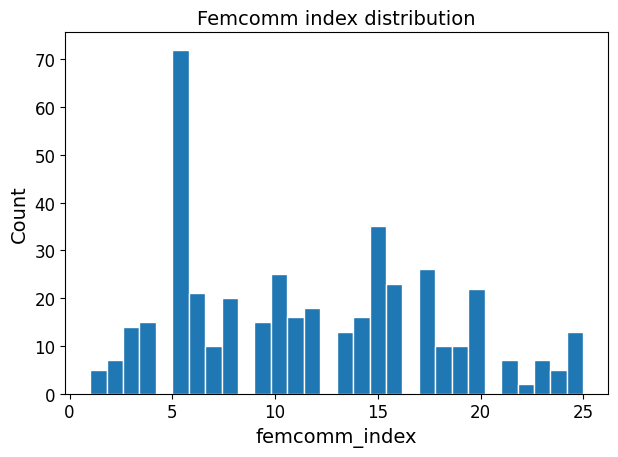

In [15]:
items = [
    "femcomm_performance",
    "femcomm_mgmt",
    "femcomm_opportunity",
    "femcomm_support",
    "femcomm_barriers",
]

# frequency tables
for col in items:
    print(col)
    print(df[col].value_counts(dropna=False).sort_index())

# Cronbach's alpha (basic implementation)
item_df = df[items].dropna()
item_scores = item_df.to_numpy(dtype=float)

k = item_scores.shape[1]
item_variances = item_scores.var(axis=0, ddof=1)
total_variance = item_scores.sum(axis=1).var(ddof=1)
alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)
print(f"Cronbach's alpha: {alpha:.3f}")

# Summative index
# (If any items require reverse coding, do that before summing.)
df["femcomm_index"] = df[items].sum(axis=1, min_count=1)
print(df["femcomm_index"].describe())

plt.figure()
plt.hist(df["femcomm_index"].dropna(), bins=30, edgecolor="white")
plt.xlabel("femcomm_index")
plt.ylabel("Count")
plt.title("Femcomm index distribution")
plt.tight_layout()


--- femcomm_performance ---
femcomm_performance
1.0    119
2.0     72
3.0     59
4.0     98
5.0     54
Name: count, dtype: int64

--- femcomm_mgmt ---
femcomm_mgmt
1.0    113
2.0     71
3.0     56
4.0    103
5.0     63
Name: count, dtype: int64

--- femcomm_opportunity ---
femcomm_opportunity
1.0    125
2.0     83
3.0     74
4.0     65
5.0     44
Name: count, dtype: int64

--- femcomm_support ---
femcomm_support
1.0    100
2.0     39
3.0     70
4.0     28
5.0     18
Name: count, dtype: int64

--- femcomm_barriers ---
femcomm_barriers
1.0     80
2.0     49
3.0     52
4.0    105
5.0     72
Name: count, dtype: int64

Cronbach's alpha: 0.958

--- Index Summary Statistics ---
count    241.000000
mean      12.879668
std        6.533730
min        5.000000
25%        5.000000
50%       13.000000
75%       18.000000
max       25.000000
Name: femcomm_index, dtype: float64


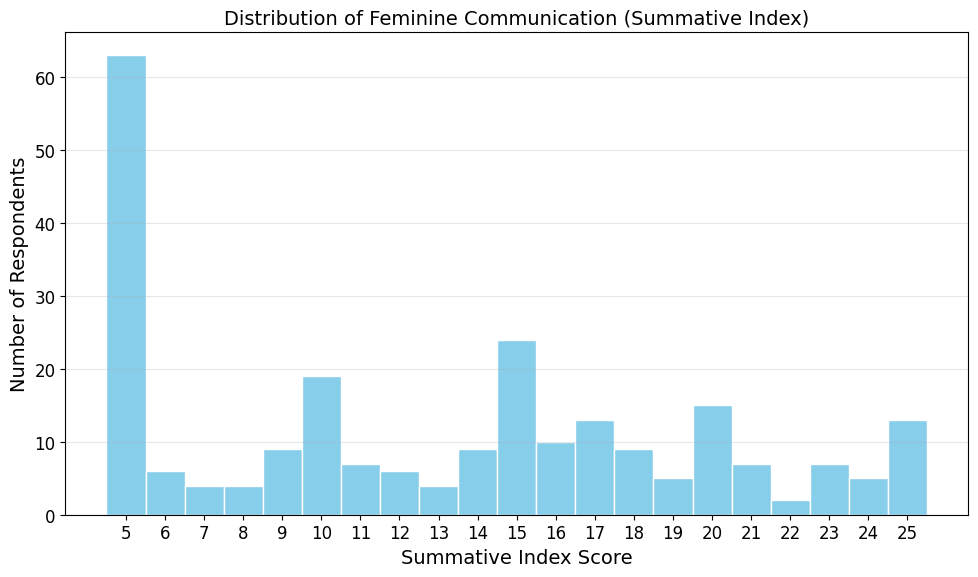

In [27]:
import numpy as np
import matplotlib.pyplot as plt

items = [
    "femcomm_performance",
    "femcomm_mgmt",
    "femcomm_opportunity",
    "femcomm_support",
    "femcomm_barriers",
]

# 1. Frequency tables (Excluding missing for the count, but showing them for audit)
for col in items:
    print(f"\n--- {col} ---")
    # Using dropna=True to see the valid distribution for your lecture
    print(df[col].value_counts(dropna=True).sort_index())

# 2. Cronbach's alpha
item_df = df[items].dropna()
item_scores = item_df.to_numpy(dtype=float)

k = item_scores.shape[1]
item_variances = item_scores.var(axis=0, ddof=1)
total_variance = item_scores.sum(axis=1).var(ddof=1)
alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)
print(f"\nCronbach's alpha: {alpha:.3f}")

# 3. Summative index
# min_count=len(items) ensures we only get a score if ALL items are answered
df["femcomm_index"] = df[items].sum(axis=1, min_count=len(items))
index_data = df["femcomm_index"].dropna()

print("\n--- Index Summary Statistics ---")
print(index_data.describe())

# 4. Histogram with discrete binning
plt.figure(figsize=(10, 6))

# Calculate discrete bins: one bin for every integer in the index range
idx_min = int(index_data.min())
idx_max = int(index_data.max())
# range(start, stop) goes to stop-1, so we add 2 to include the final bar edge
bins_discrete = range(idx_min, idx_max + 2)

plt.hist(index_data, bins=bins_discrete, edgecolor="white", align='left', color='skyblue')

# Force x-ticks to be integers so they align with the index values
plt.xticks(range(idx_min, idx_max + 1))

plt.xlabel("Summative Index Score")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Feminine Communication (Summative Index)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Step 4: Hypothesis test (gender differences)

Compare index means between genders (female vs male). Use a two-sample t-test.

In [28]:
from scipy import stats

# Use actual Gender labels from the dataset
female = df[df["Gender"] == "Female"]["femcomm_index"].dropna()
male = df[df["Gender"] == "Male"]["femcomm_index"].dropna()

print("Female mean:", female.mean())
print("Male mean:", male.mean())

# Welch's t-test (does not assume equal variances)
res = stats.ttest_ind(female, male, equal_var=False)
print(res)

Female mean: 14.602484472049689
Male mean: 9.074626865671641
TtestResult(statistic=np.float64(6.979168009228572), pvalue=np.float64(8.090511271065262e-11), df=np.float64(155.36834016726473))


Interpretation: if the p-value is below 0.05, the difference is statistically significant.

---

## Wrap-up

You now have a Python-based workflow for the descriptive statistics and data transformation tasks in Workshops 1 and 2. Save this notebook as `jnb/lab1.ipynb` via Quarto conversion when you are ready.